抽取100条帖子

In [1]:
import pandas as pd
import numpy as np

# 读取原始数据
df = pd.read_csv('step4_post_sentiment.csv')

# 随机抽取 100 条
np.random.seed(42)
sample = df.sample(n=100, replace=False).copy()

# 选择列
sample = sample[['post_id', 'full_text', 'sentiment_score']]

# 待人工标注列
sample['human_label'] = ''

# 保存
sample.to_csv('finbert_validation_sample.csv', index=False, encoding='utf-8-sig')
print(f"已抽取 {len(sample)} 条帖子，保存为 finbert_validation_sample.csv")
print("请用 Excel 打开，在 human_label 列中标注：1=正面情绪，0=负面情绪")

已抽取 100 条帖子，保存为 finbert_validation_sample.csv
请用 Excel 打开，在 human_label 列中标注：1=正面情绪，0=负面情绪


检查finbert情绪评分的正确率

In [2]:
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 读取标注文件
df = pd.read_csv('finbert_validation_sample.csv')

# 检查列名，确保有 'sentiment_score' 和 'human_label'
print("列名:", df.columns.tolist())

# 将 human_label 转换为整数（如果已经是则无需）
df['human_label'] = df['human_label'].astype(int)

# FinBERT 分数映射为三分类（阈值 ±0.1）
def finbert_to_class(score):
    if score > 0.1:
        return 1
    elif score < -0.1:
        return -1
    else:
        return 0

df['finbert_class'] = df['sentiment_score'].apply(finbert_to_class)

# 计算准确率
acc = accuracy_score(df['human_label'], df['finbert_class'])
print(f"\n三分类准确率 (阈值 ±0.1): {acc:.2%}")

# 混淆矩阵
cm = confusion_matrix(df['human_label'], df['finbert_class'], labels=[-1, 0, 1])
print("\n混淆矩阵 (行: 真实, 列: 预测)")
print("           Pred -1   Pred 0   Pred 1")
print(f"True -1:   {cm[0,0]:5d}   {cm[0,1]:5d}   {cm[0,2]:5d}")
print(f"True  0:   {cm[1,0]:5d}   {cm[1,1]:5d}   {cm[1,2]:5d}")
print(f"True  1:   {cm[2,0]:5d}   {cm[2,1]:5d}   {cm[2,2]:5d}")

# 分类报告
print("\n分类报告 (macro average):")
print(classification_report(df['human_label'], df['finbert_class'], labels=[-1,0,1], target_names=['Negative', 'Neutral', 'Positive']))

# 可选：输出错误预测的示例
errors = df[df['human_label'] != df['finbert_class']]
print(f"\n错误预测数量: {len(errors)}")
if len(errors) > 0:
    print("\n前10个错误示例:")
    for _, row in errors.head(10).iterrows():
        print(f"post_id={row['post_id']} | human={row['human_label']} | finbert_score={row['sentiment_score']:.3f} | finbert_class={row['finbert_class']}")

列名: ['post_id', 'full_text', 'sentiment_score', 'human_label']

三分类准确率 (阈值 ±0.1): 73.00%

混淆矩阵 (行: 真实, 列: 预测)
           Pred -1   Pred 0   Pred 1
True -1:       5       5       6
True  0:       2       4      12
True  1:       1       1      64

分类报告 (macro average):
              precision    recall  f1-score   support

    Negative       0.62      0.31      0.42        16
     Neutral       0.40      0.22      0.29        18
    Positive       0.78      0.97      0.86        66

    accuracy                           0.73       100
   macro avg       0.60      0.50      0.52       100
weighted avg       0.69      0.73      0.69       100


错误预测数量: 27

前10个错误示例:
post_id=1icby6f | human=-1 | finbert_score=0.158 | finbert_class=1
post_id=1kgc2e3 | human=-1 | finbert_score=0.014 | finbert_class=0
post_id=1amo3hn | human=0 | finbert_score=0.637 | finbert_class=1
post_id=1f6xj6f | human=1 | finbert_score=0.095 | finbert_class=0
post_id=1l9mlz0 | human=0 | finbert_score=0.794 | finbert_cla

窗口设置：train（120）

In [20]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import recall_score, roc_auc_score

# ==================== 配置 ====================
TRAIN_WINDOW = 120          # 训练窗口固定为120周
COST_FN = 10.0
COST_FP = 1.0
C_BEST = 0.01               # 根据调参结果修改 (0.01 或 0.001)

# ==================== 1. 数据加载与特征工程 ====================
df = pd.read_csv('final_combined_base_20pct.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

def add_technical_indicators(win_df):
    df_win = win_df.copy()
    df_win['MA20'] = df_win['Close'].rolling(20, min_periods=1).mean()
    df_win['MA_Bias'] = (df_win['Close'] - df_win['MA20']) / df_win['MA20']
    df_win['TR'] = df_win['High'] - df_win['Low']
    df_win['ATR'] = df_win['TR'].rolling(14, min_periods=1).mean()
    delta = df_win['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(14, min_periods=1).mean()
    avg_loss = loss.rolling(14, min_periods=1).mean()
    rs = avg_gain / avg_loss
    df_win['RSI'] = 100 - (100 / (1 + rs))
    df_win['Volume_Change'] = df_win['Volume'].pct_change()
    return df_win

def add_sentiment_indicators(win_df):
    df_win = win_df.copy()
    df_win['Sentiment_Level'] = df_win['sentiment_score']
    df_win['Sentiment_Uncertainty'] = df_win['sentiment_score'].rolling(4, min_periods=1).std()
    df_win['Volume_Spike'] = df_win['post_count'] / df_win['post_count'].rolling(4, min_periods=1).mean()
    df_win['Volume_Spike'] = df_win['Volume_Spike'].clip(upper=5)
    return df_win

def add_divergence_feature(win_df):
    df_win = win_df.copy()
    price_dir = np.sign(df_win['Close'].diff())
    sentiment_dir = np.sign(df_win['sentiment_score'].diff())
    df_win['Price_Sentiment_Divergence'] = (price_dir * sentiment_dir == -1).astype(int)
    df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
    return df_win

def add_risk_resonance(win_df):
    df_win = win_df.copy()
    uncertainty_median = df_win['Sentiment_Uncertainty'].rolling(4, min_periods=1).median()
    df_win['Risk_Resonance'] = ((df_win['Sentiment_Uncertainty'] > uncertainty_median) & (df_win['VIX_Trend'] > 0)).astype(int)
    return df_win

df = add_technical_indicators(df)
df = add_sentiment_indicators(df)
df = add_divergence_feature(df)
df = add_risk_resonance(df)

features = [
    'MA_Bias', 'ATR', 'RSI', 'Volume_Change',
    'Sentiment_Level', 'Sentiment_Uncertainty', 'Volume_Spike',
    'VIX_Trend', 'yield_spread',
    'Price_Sentiment_Divergence', 'Risk_Resonance'
]
X = df[features]
y = df['next_week_risk']

# ==================== 2. 滚动窗口 + 成本法阈值 (滚动120周) ====================
TOTAL_WEEKS = len(X)
print(f"总样本数: {TOTAL_WEEKS}, 训练窗口: {TRAIN_WINDOW} 周, 预测次数: {TOTAL_WEEKS - TRAIN_WINDOW}")

results = {'true': [], 'prob': [], 'pred': [], 'threshold': []}
for test_idx in range(TRAIN_WINDOW, TOTAL_WEEKS):
    # 训练集: [test_idx - TRAIN_WINDOW, test_idx)
    train_raw = X.iloc[test_idx - TRAIN_WINDOW : test_idx]
    test_raw = X.iloc[test_idx : test_idx+1]
    y_train_raw = y.iloc[test_idx - TRAIN_WINDOW : test_idx]
    y_test = y.iloc[test_idx]

    # 删除训练集中含有NaN的行
    train_data = train_raw.dropna()
    y_train = y_train_raw.loc[train_data.index]
    if len(train_data) < 50:
        continue

    # 划分验证集（最后20%）
    split = int(len(train_data) * 0.8)
    X_tr, X_val = train_data.iloc[:split], train_data.iloc[split:]
    y_tr, y_val = y_train.iloc[:split], y_train.iloc[split:]

    # 模型
    model = make_pipeline(StandardScaler(),
                          LogisticRegression(C=C_BEST, penalty='l2', class_weight='balanced', max_iter=1000))
    model.fit(X_tr, y_tr)

    # 验证集概率
    probs_val = model.predict_proba(X_val)[:, 1]

    # 成本法搜索最优阈值
    best_thr = 0.5
    min_cost = float('inf')
    for thr in np.arange(0.1, 0.6, 0.01):
        pred_val = (probs_val >= thr).astype(int)
        fn = np.sum((y_val == 1) & (pred_val == 0))
        fp = np.sum((y_val == 0) & (pred_val == 1))
        cost = COST_FN * fn + COST_FP * fp
        if cost < min_cost:
            min_cost = cost
            best_thr = thr

    # 测试集预测
    test_data = test_raw.dropna()
    if len(test_data) == 0:
        continue
    prob_test = model.predict_proba(test_data)[0][1]
    pred_test = (prob_test >= best_thr).astype(int)

    results['true'].append(y_test)
    results['prob'].append(prob_test)
    results['pred'].append(pred_test)
    results['threshold'].append(best_thr)

    # 可选：打印进度
    if (test_idx - TRAIN_WINDOW + 1) % 10 == 0:
        print(f"已完成 {test_idx - TRAIN_WINDOW + 1}/{TOTAL_WEEKS - TRAIN_WINDOW} 次预测")

# ==================== 3. 评估 ====================
df_res = pd.DataFrame(results)
recall = recall_score(df_res['true'], df_res['pred'])
auc = roc_auc_score(df_res['true'], df_res['prob'])
avg_thr = df_res['threshold'].mean()
print(f"\n最终模型 (C={C_BEST}, 训练窗口={TRAIN_WINDOW})")
print(f"预测次数: {len(df_res)}")
print(f"召回率 (Recall) = {recall:.4f}")
print(f"AUC = {auc:.4f}")
print(f"平均最优阈值 = {avg_thr:.3f}")

# 保存结果
df_res.to_csv(f'logistic_C{C_BEST}_win{TRAIN_WINDOW}_cost.csv', index=False)
print(f"结果已保存至 logistic_C{C_BEST}_win{TRAIN_WINDOW}_cost.csv")

总样本数: 157, 训练窗口: 120 周, 预测次数: 37
已完成 10/37 次预测
已完成 20/37 次预测
已完成 30/37 次预测

最终模型 (C=0.01, 训练窗口=120)
预测次数: 37
召回率 (Recall) = 0.7143
AUC = 0.4762
平均最优阈值 = 0.455
结果已保存至 logistic_C0.01_win120_cost.csv


# **三个模型独立调参与比较（成本阈值法）**

复合指标

logestic regression

In [1]:
# ==================== 完整代码：20%阈值 + 实验三 + 成本法阈值调优（以 Recall×AUC 为评判标准） ====================
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import recall_score, f1_score, roc_auc_score

print("="*60)
print("20% 阈值 | 实验三: 技术+情绪+宏观+背离+共振 | 成本法阈值 (FN=10, FP=1)")
print("评判标准: 复合得分 = Recall × AUC")
print("="*60)

# -------------------- 1. 数据加载 --------------------
df = pd.read_csv('final_combined_base_20pct.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"总样本数: {len(df)}")
print(f"日期范围: {df['Date'].min()} 至 {df['Date'].max()}")
print(f"VIX_Trend 缺失数: {df['VIX_Trend'].isna().sum()}")
print(f"yield_spread 缺失数: {df['yield_spread'].isna().sum()}")
print(f"正例比例: {df['next_week_risk'].mean():.2%}")

# -------------------- 2. 滚动参数 --------------------
TRAIN_WINDOW = 100
TOTAL_WEEKS = len(df)
print(f"训练窗口: {TRAIN_WINDOW} 周, 总周数: {TOTAL_WEEKS}, 预测次数: {TOTAL_WEEKS - TRAIN_WINDOW}")

# -------------------- 3. 特征计算函数 --------------------
def add_technical_indicators(win_df):
    df_win = win_df.copy()
    df_win['MA20'] = df_win['Close'].rolling(20, min_periods=1).mean()
    df_win['MA_Bias'] = (df_win['Close'] - df_win['MA20']) / df_win['MA20']
    df_win['TR'] = df_win['High'] - df_win['Low']
    df_win['ATR'] = df_win['TR'].rolling(14, min_periods=1).mean()
    delta = df_win['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(14, min_periods=1).mean()
    avg_loss = loss.rolling(14, min_periods=1).mean()
    rs = avg_gain / avg_loss
    df_win['RSI'] = 100 - (100 / (1 + rs))
    df_win['Volume_Change'] = df_win['Volume'].pct_change()
    return df_win

def add_sentiment_indicators(win_df):
    df_win = win_df.copy()
    df_win['Sentiment_Level'] = df_win['sentiment_score']
    df_win['Sentiment_Uncertainty'] = df_win['sentiment_score'].rolling(4, min_periods=1).std()
    df_win['Volume_Spike'] = df_win['post_count'] / df_win['post_count'].rolling(4, min_periods=1).mean()
    df_win['Volume_Spike'] = df_win['Volume_Spike'].clip(upper=5)
    return df_win

def add_divergence_feature(win_df):
    df_win = win_df.copy()
    price_dir = np.sign(df_win['Close'].diff())
    sentiment_dir = np.sign(df_win['sentiment_score'].diff())
    df_win['Price_Sentiment_Divergence'] = (price_dir * sentiment_dir == -1).astype(int)
    df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
    return df_win

def add_risk_resonance(win_df):
    df_win = win_df.copy()
    uncertainty_median = df_win['Sentiment_Uncertainty'].rolling(4, min_periods=1).median()
    df_win['Risk_Resonance'] = ((df_win['Sentiment_Uncertainty'] > uncertainty_median) & (df_win['VIX_Trend'] > 0)).astype(int)
    return df_win

# -------------------- 4. 实验三的特征列表 --------------------
features_exp3 = [
    'MA_Bias', 'ATR', 'RSI', 'Volume_Change',
    'Sentiment_Level', 'Sentiment_Uncertainty', 'Volume_Spike',
    'VIX_Trend', 'yield_spread',
    'Price_Sentiment_Divergence', 'Risk_Resonance'
]

# -------------------- 5. 成本参数 --------------------
COST_FN = 10.0
COST_FP = 1.0

# -------------------- 6. 待搜索的 C 值列表 --------------------
C_values = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]   # 可自行增减
results_summary = []

for C in C_values:
    print(f"\n正在测试 C = {C} ...")
    results = {'true': [], 'prob': [], 'pred': [], 'threshold': []}
    total_iters = TOTAL_WEEKS - TRAIN_WINDOW

    for test_idx in range(TRAIN_WINDOW, TOTAL_WEEKS):
        # 提取窗口
        train_raw = df.iloc[test_idx - TRAIN_WINDOW : test_idx]
        test_raw = df.iloc[test_idx : test_idx+1]
        window_raw = pd.concat([train_raw, test_raw], axis=0).reset_index(drop=True)

        # 计算所有特征
        window_feat = add_technical_indicators(window_raw)
        window_feat = add_sentiment_indicators(window_feat)
        window_feat = add_divergence_feature(window_feat)
        window_feat = add_risk_resonance(window_feat)

        X_train_full = window_feat.iloc[:-1]
        X_test = window_feat.iloc[-1:]
        y_train = X_train_full['next_week_risk'].values
        y_test = X_test['next_week_risk'].values[0]

        X_train = X_train_full[features_exp3].dropna()
        if len(X_train) < 50:
            continue
        train_idx = X_train.index
        y_train_aligned = y_train[train_idx]

        X_test_feat = X_test[features_exp3].dropna()
        if len(X_test_feat) == 0:
            continue

        # 划分验证集
        split = int(len(X_train) * 0.8)
        X_tr, X_val = X_train[:split], X_train[split:]
        y_tr, y_val = y_train_aligned[:split], y_train_aligned[split:]

        # 使用当前 C 值训练模型
        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(penalty='l2', C=C, class_weight='balanced', max_iter=1000)
        )
        model.fit(X_tr, y_tr)

        probs_val = model.predict_proba(X_val)[:, 1]

        # 成本法搜索最优阈值
        best_threshold = 0.5
        min_cost = float('inf')
        for thr in np.arange(0.1, 0.6, 0.01):
            y_pred_val = (probs_val >= thr).astype(int)
            fn = np.sum((y_val == 1) & (y_pred_val == 0))
            fp = np.sum((y_val == 0) & (y_pred_val == 1))
            cost = COST_FN * fn + COST_FP * fp
            if cost < min_cost:
                min_cost = cost
                best_threshold = thr

        y_prob = model.predict_proba(X_test_feat)[0][1]
        y_pred = (y_prob >= best_threshold).astype(int)

        results['true'].append(y_test)
        results['prob'].append(y_prob)
        results['pred'].append(y_pred)
        results['threshold'].append(best_threshold)

    # 汇总指标
    df_res = pd.DataFrame(results)
    if len(df_res) == 0:
        print(f"C={C}: 无有效预测")
        continue
    recall = recall_score(df_res['true'], df_res['pred'])
    f1 = f1_score(df_res['true'], df_res['pred'])
    auc = roc_auc_score(df_res['true'], df_res['prob'])
    avg_thr = df_res['threshold'].mean()
    composite = recall * auc   # 复合得分
    results_summary.append({
        'C': C,
        'Recall': recall,
        'F1': f1,
        'AUC': auc,
        'Composite': composite,
        'Avg_Threshold': avg_thr,
        'Predictions': len(df_res)
    })
    print(f"  C={C}: Recall={recall:.4f}, AUC={auc:.4f}, Composite={composite:.4f}, Avg_Thr={avg_thr:.3f}")

# -------------------- 输出汇总表格（按复合得分排序） --------------------
print("\n" + "="*60)
print("C 值调优结果汇总（按 Composite = Recall × AUC 排序）")
print("="*60)
summary_df = pd.DataFrame(results_summary).sort_values('Composite', ascending=False)
print(summary_df.to_string(index=False))

# 找出最佳 C（以复合得分为优先）
best_row = summary_df.loc[summary_df['Composite'].idxmax()]
print(f"\n推荐 C 值: {best_row['C']} (复合得分 {best_row['Composite']:.4f}, Recall={best_row['Recall']:.4f}, AUC={best_row['AUC']:.4f})")

20% 阈值 | 实验三: 技术+情绪+宏观+背离+共振 | 成本法阈值 (FN=10, FP=1)
评判标准: 复合得分 = Recall × AUC
总样本数: 157
日期范围: 2023-01-06 00:00:00 至 2026-01-02 00:00:00
VIX_Trend 缺失数: 19
yield_spread 缺失数: 0
正例比例: 19.75%
训练窗口: 100 周, 总周数: 157, 预测次数: 57

正在测试 C = 0.01 ...


/tmp/ipykernel_13294/1783428100.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
/tmp/ipykernel_13294/1783428100.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

  C=0.01: Recall=0.8667, AUC=0.6254, Composite=0.5420, Avg_Thr=0.469

正在测试 C = 0.05 ...


/tmp/ipykernel_13294/1783428100.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
/tmp/ipykernel_13294/1783428100.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

  C=0.05: Recall=0.7333, AUC=0.6190, Composite=0.4540, Avg_Thr=0.400

正在测试 C = 0.1 ...


...

/tmp/ipykernel_13294/1783428100.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
/tmp/ipykernel_13294/1783428100.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

  C=5.0: Recall=0.8000, AUC=0.5746, Composite=0.4597, Avg_Thr=0.279

正在测试 C = 10.0 ...


/tmp/ipykernel_13294/1783428100.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
/tmp/ipykernel_13294/1783428100.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

  C=10.0: Recall=0.8000, AUC=0.5714, Composite=0.4571, Avg_Thr=0.272

C 值调优结果汇总（按 Composite = Recall × AUC 排序）
    C   Recall       F1      AUC  Composite  Avg_Threshold  Predictions
 0.01 0.866667 0.426230 0.625397   0.542011       0.468947           57
 0.10 0.800000 0.393443 0.612698   0.490159       0.370877           57
 5.00 0.800000 0.393443 0.574603   0.459683       0.278772           57
 1.00 0.800000 0.393443 0.574603   0.459683       0.297895           57
10.00 0.800000 0.393443 0.571429   0.457143       0.271930           57
 0.05 0.733333 0.372881 0.619048   0.453968       0.400351           57
 0.50 0.733333 0.354839 0.584127   0.428360       0.314211           57

推荐 C 值: 0.01 (复合得分 0.5420, Recall=0.8667, AUC=0.6254)


/tmp/ipykernel_13294/1783428100.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)


random forest

In [2]:
# ==================== 随机森林调优：20%阈值 + 实验三 + 成本法阈值 + 复合得分 ====================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("随机森林调优 | 20% 阈值 | 实验三 (全特征) | 成本法阈值 (FN=10, FP=1)")
print("评判标准: 复合得分 = Recall × AUC")
print("="*60)

# -------------------- 1. 数据加载与特征工程 --------------------
df = pd.read_csv('final_combined_base_20pct.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

def add_technical_indicators(win_df):
    df_win = win_df.copy()
    df_win['MA20'] = df_win['Close'].rolling(20, min_periods=1).mean()
    df_win['MA_Bias'] = (df_win['Close'] - df_win['MA20']) / df_win['MA20']
    df_win['TR'] = df_win['High'] - df_win['Low']
    df_win['ATR'] = df_win['TR'].rolling(14, min_periods=1).mean()
    delta = df_win['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(14, min_periods=1).mean()
    avg_loss = loss.rolling(14, min_periods=1).mean()
    rs = avg_gain / avg_loss
    df_win['RSI'] = 100 - (100 / (1 + rs))
    df_win['Volume_Change'] = df_win['Volume'].pct_change()
    return df_win

def add_sentiment_indicators(win_df):
    df_win = win_df.copy()
    df_win['Sentiment_Level'] = df_win['sentiment_score']
    df_win['Sentiment_Uncertainty'] = df_win['sentiment_score'].rolling(4, min_periods=1).std()
    df_win['Volume_Spike'] = df_win['post_count'] / df_win['post_count'].rolling(4, min_periods=1).mean()
    df_win['Volume_Spike'] = df_win['Volume_Spike'].clip(upper=5)
    return df_win

def add_divergence_feature(win_df):
    df_win = win_df.copy()
    price_dir = np.sign(df_win['Close'].diff())
    sentiment_dir = np.sign(df_win['sentiment_score'].diff())
    df_win['Price_Sentiment_Divergence'] = (price_dir * sentiment_dir == -1).astype(int)
    df_win['Price_Sentiment_Divergence'].fillna(0, inplace=True)
    return df_win

def add_risk_resonance(win_df):
    df_win = win_df.copy()
    uncertainty_median = df_win['Sentiment_Uncertainty'].rolling(4, min_periods=1).median()
    df_win['Risk_Resonance'] = ((df_win['Sentiment_Uncertainty'] > uncertainty_median) & (df_win['VIX_Trend'] > 0)).astype(int)
    return df_win

df = add_technical_indicators(df)
df = add_sentiment_indicators(df)
df = add_divergence_feature(df)
df = add_risk_resonance(df)

features = [
    'MA_Bias', 'ATR', 'RSI', 'Volume_Change',
    'Sentiment_Level', 'Sentiment_Uncertainty', 'Volume_Spike',
    'VIX_Trend', 'yield_spread',
    'Price_Sentiment_Divergence', 'Risk_Resonance'
]
X = df[features]
y = df['next_week_risk']

# -------------------- 2. 滚动窗口参数 --------------------
TRAIN_WINDOW = 100
TOTAL_WEEKS = len(X)
COST_FN = 10
COST_FP = 1

# -------------------- 3. 成本法评估函数（适用于随机森林） --------------------
def evaluate_rf_cost_sensitive(params, X, y, train_window=TRAIN_WINDOW, cost_fn=COST_FN, cost_fp=COST_FP):
    all_true = []
    all_prob = []
    all_pred = []
    for test_idx in range(train_window, TOTAL_WEEKS):
        train_raw = X.iloc[test_idx - train_window : test_idx]
        test_raw = X.iloc[test_idx : test_idx+1]
        y_train_raw = y.iloc[test_idx - train_window : test_idx]
        y_test = y.iloc[test_idx]

        train_data = train_raw.dropna()
        y_train = y_train_raw.loc[train_data.index]
        if len(train_data) < 50:
            continue

        split = int(len(train_data) * 0.8)
        X_tr, X_val = train_data.iloc[:split], train_data.iloc[split:]
        y_tr, y_val = y_train.iloc[:split], y_train.iloc[split:]

        model = RandomForestClassifier(**params, random_state=42)
        model.fit(X_tr, y_tr)

        probs_val = model.predict_proba(X_val)[:, 1]

        best_thr = 0.5
        min_cost = float('inf')
        for thr in np.arange(0.1, 0.6, 0.01):
            pred_val = (probs_val >= thr).astype(int)
            fn = np.sum((y_val == 1) & (pred_val == 0))
            fp = np.sum((y_val == 0) & (pred_val == 1))
            cost = cost_fn * fn + cost_fp * fp
            if cost < min_cost:
                min_cost = cost
                best_thr = thr

        test_data = test_raw.dropna()
        if len(test_data) == 0:
            continue
        prob_test = model.predict_proba(test_data)[0][1]
        pred_test = (prob_test >= best_thr).astype(int)

        all_true.append(y_test)
        all_prob.append(prob_test)
        all_pred.append(pred_test)

    if len(all_true) == 0:
        return 0, 0
    recall = recall_score(all_true, all_pred)
    try:
        auc = roc_auc_score(all_true, all_prob)
    except:
        auc = 0.5
    return recall, auc

# -------------------- 4. 参数网格 --------------------
rf_param_grid = [
    {'n_estimators': 50, 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 5, 'class_weight': 'balanced'},
    {'n_estimators': 50, 'max_depth': 3, 'min_samples_leaf': 6, 'min_samples_split': 10, 'class_weight': 'balanced'},
    {'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 5, 'class_weight': 'balanced'},
    {'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 6, 'min_samples_split': 10, 'class_weight': 'balanced'},
    {'n_estimators': 150, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 5, 'class_weight': 'balanced'},
]

# -------------------- 5. 遍历参数，计算复合得分 --------------------
results = []
for params in rf_param_grid:
    recall, auc = evaluate_rf_cost_sensitive(params, X, y)
    comp = recall * auc
    results.append((params, recall, auc, comp))
    print(f"RF: {params} -> Recall={recall:.4f}, AUC={auc:.4f}, Comp={comp:.4f}")

best = max(results, key=lambda x: x[3])
print("\n" + "="*60)
print("随机森林最佳参数:")
print(f"  {best[0]}")
print(f"  Recall = {best[1]:.4f}, AUC = {best[2]:.4f}, Composite = {best[3]:.4f}")

随机森林调优 | 20% 阈值 | 实验三 (全特征) | 成本法阈值 (FN=10, FP=1)
评判标准: 复合得分 = Recall × AUC
RF: {'n_estimators': 50, 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 5, 'class_weight': 'balanced'} -> Recall=0.7333, AUC=0.5540, Comp=0.4062
RF: {'n_estimators': 50, 'max_depth': 3, 'min_samples_leaf': 6, 'min_samples_split': 10, 'class_weight': 'balanced'} -> Recall=0.7333, AUC=0.5619, Comp=0.4121
RF: {'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 5, 'class_weight': 'balanced'} -> Recall=0.9333, AUC=0.5492, Comp=0.5126
RF: {'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 6, 'min_samples_split': 10, 'class_weight': 'balanced'} -> Recall=0.8667, AUC=0.5683, Comp=0.4925
RF: {'n_estimators': 150, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 5, 'class_weight': 'balanced'} -> Recall=0.8667, AUC=0.5270, Comp=0.4567

随机森林最佳参数:
  {'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 5, 'class_weight': 'balanced'}
  R

xgboost

In [3]:
# ==================== XGBoost 调优：20%阈值 + 实验三 + 成本法阈值 + 复合得分 ====================
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("XGBoost 调优 | 20% 阈值 | 实验三 (全特征) | 成本法阈值 (FN=10, FP=1)")
print("评判标准: 复合得分 = Recall × AUC")
print("="*60)

# -------------------- 1. 数据加载与特征工程（同前，略，假设已执行） --------------------
# 请确保前面已经运行了特征计算代码，并得到 X, y
# 这里直接复用前面的 X, y 变量，所以建议将此代码与前面的特征计算部分放在同一个脚本中
# 为了独立运行，这里再次提供特征计算代码（与随机森林部分相同，可以复制）
# 为了简洁，此处假设 X, y 已经存在（如果单独运行，需复制上面的特征工程部分）

# -------------------- 2. 滚动窗口参数 --------------------
TRAIN_WINDOW = 100
TOTAL_WEEKS = len(X)
COST_FN = 10
COST_FP = 1

# -------------------- 3. 成本法评估函数（适用于 XGBoost） --------------------
def evaluate_xgb_cost_sensitive(params, X, y, train_window=TRAIN_WINDOW, cost_fn=COST_FN, cost_fp=COST_FP):
    all_true = []
    all_prob = []
    all_pred = []
    for test_idx in range(train_window, TOTAL_WEEKS):
        train_raw = X.iloc[test_idx - train_window : test_idx]
        test_raw = X.iloc[test_idx : test_idx+1]
        y_train_raw = y.iloc[test_idx - train_window : test_idx]
        y_test = y.iloc[test_idx]

        train_data = train_raw.dropna()
        y_train = y_train_raw.loc[train_data.index]
        if len(train_data) < 50:
            continue

        split = int(len(train_data) * 0.8)
        X_tr, X_val = train_data.iloc[:split], train_data.iloc[split:]
        y_tr, y_val = y_train.iloc[:split], y_train.iloc[split:]

        model = XGBClassifier(**params, random_state=42, use_label_encoder=False, eval_metric='logloss')
        model.fit(X_tr, y_tr)

        probs_val = model.predict_proba(X_val)[:, 1]

        best_thr = 0.5
        min_cost = float('inf')
        for thr in np.arange(0.1, 0.6, 0.01):
            pred_val = (probs_val >= thr).astype(int)
            fn = np.sum((y_val == 1) & (pred_val == 0))
            fp = np.sum((y_val == 0) & (pred_val == 1))
            cost = cost_fn * fn + cost_fp * fp
            if cost < min_cost:
                min_cost = cost
                best_thr = thr

        test_data = test_raw.dropna()
        if len(test_data) == 0:
            continue
        prob_test = model.predict_proba(test_data)[0][1]
        pred_test = (prob_test >= best_thr).astype(int)

        all_true.append(y_test)
        all_prob.append(prob_test)
        all_pred.append(pred_test)

    if len(all_true) == 0:
        return 0, 0
    recall = recall_score(all_true, all_pred)
    try:
        auc = roc_auc_score(all_true, all_prob)
    except:
        auc = 0.5
    return recall, auc

# -------------------- 4. 参数网格 --------------------
xgb_param_grid = [
    {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.05, 'subsample': 0.7, 'scale_pos_weight': 2},
    {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.05, 'subsample': 0.7, 'scale_pos_weight': 3},
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'scale_pos_weight': 3},
    {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'scale_pos_weight': 3},
    {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'scale_pos_weight': 4},
]

# -------------------- 5. 遍历参数，计算复合得分 --------------------
results = []
for params in xgb_param_grid:
    recall, auc = evaluate_xgb_cost_sensitive(params, X, y)
    comp = recall * auc
    results.append((params, recall, auc, comp))
    print(f"XGB: {params} -> Recall={recall:.4f}, AUC={auc:.4f}, Comp={comp:.4f}")

best = max(results, key=lambda x: x[3])
print("\n" + "="*60)
print("XGBoost 最佳参数:")
print(f"  {best[0]}")
print(f"  Recall = {best[1]:.4f}, AUC = {best[2]:.4f}, Composite = {best[3]:.4f}")

XGBoost 调优 | 20% 阈值 | 实验三 (全特征) | 成本法阈值 (FN=10, FP=1)
评判标准: 复合得分 = Recall × AUC
XGB: {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.05, 'subsample': 0.7, 'scale_pos_weight': 2} -> Recall=0.8667, AUC=0.5603, Comp=0.4856
XGB: {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.05, 'subsample': 0.7, 'scale_pos_weight': 3} -> Recall=0.8000, AUC=0.5413, Comp=0.4330
XGB: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'scale_pos_weight': 3} -> Recall=0.6667, AUC=0.5508, Comp=0.3672
XGB: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'scale_pos_weight': 3} -> Recall=0.4667, AUC=0.5714, Comp=0.2667
XGB: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'scale_pos_weight': 4} -> Recall=0.5333, AUC=0.6095, Comp=0.3251

XGBoost 最佳参数:
  {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.05, 'subsample': 0.7, 'scale_pos_weight': 2}
  Recall = 0.8667, AUC = 0.5603, Composite = 0.4856


生成累计收益率曲线图

预测次数: 57


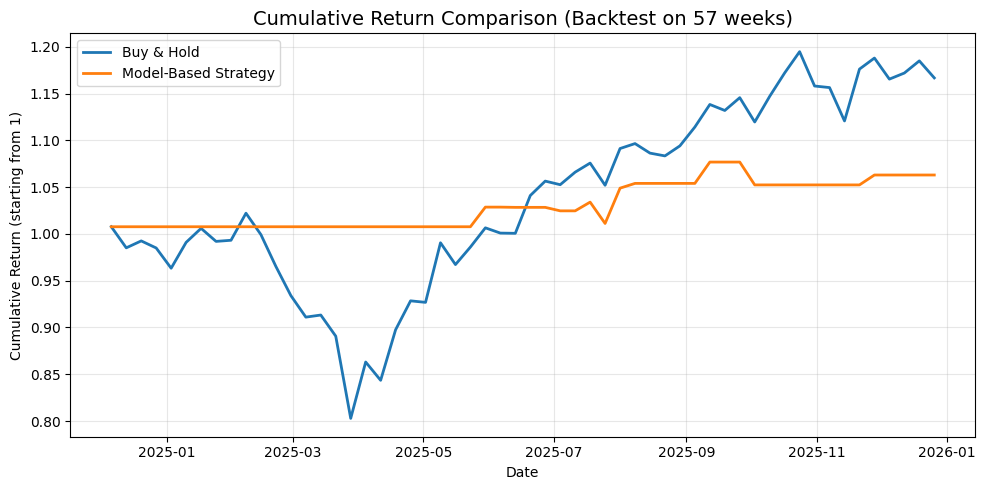

✅ 累计收益率曲线已保存为 backtest_cumulative_return.png


In [3]:
# generate_backtest_chart.py (无需预测文件中的日期列)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取预测结果 (只有 true, prob, pred, threshold)
pred_df = pd.read_csv('final_model_predictions.csv')
n_pred = len(pred_df)
print(f"预测次数: {n_pred}")

# 读取周度价格数据 (必须包含 Date 和 Close)
price_df = pd.read_csv('weekly_price_data.csv', parse_dates=['Date'])
price_df = price_df.sort_values('Date').reset_index(drop=True)

# 滚动窗口: 第一次预测对应价格数据索引100 (第101周)
start_idx = 100
if start_idx + n_pred <= len(price_df):
    test_dates = price_df.iloc[start_idx:start_idx + n_pred]['Date'].values
else:
    raise ValueError("价格数据长度不足，无法对齐预测")

# 计算每周收益率 (下周收益率)
price_df['next_return'] = price_df['Close'].pct_change().shift(-1)

# 提取每次预测对应的下周收益率
next_returns = []
for i in range(n_pred):
    idx = start_idx + i
    if idx < len(price_df) - 1:
        next_returns.append(price_df.loc[idx, 'next_return'])
    else:
        next_returns.append(np.nan)
next_returns = next_returns[:n_pred]

df_backtest = pd.DataFrame({
    'date': test_dates,
    'pred': pred_df['pred'].values,
    'next_return': next_returns
}).dropna()

# 计算策略收益
df_backtest['bench_return'] = df_backtest['next_return']
df_backtest['strat_return'] = np.where(df_backtest['pred'] == 1, 0, df_backtest['next_return'])
df_backtest['bench_cum'] = (1 + df_backtest['bench_return']).cumprod()
df_backtest['strat_cum'] = (1 + df_backtest['strat_return']).cumprod()

# 绘图
plt.figure(figsize=(10, 5))
plt.plot(df_backtest['date'], df_backtest['bench_cum'], label='Buy & Hold', linewidth=2)
plt.plot(df_backtest['date'], df_backtest['strat_cum'], label='Model-Based Strategy', linewidth=2)
plt.title('Cumulative Return Comparison (Backtest on 57 weeks)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Return (starting from 1)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('backtest_cumulative_return.png', dpi=300)
plt.show()
print("✅ 累计收益率曲线已保存为 backtest_cumulative_return.png")